# Pipeline Completo: Predicción de Segundo Matrimonio
> Preprocesamiento → Modelos Random Forest → Evaluación Final

## Paso 1 · Imports y Configuración

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)
from imblearn.over_sampling import SMOTE

# ── Configuración global ──────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.30

RUTAS = {
    "matrimonios": "data_matrimonios",
    "divorcios":   "data_divorcios",
}

ARCHIVOS = {
    "matrimonios": [
        "matrimonios_2019.sav", "matrimonios_2020.sav", "matrimonios_2021.sav",
        "matrimonios_2022.sav", "matrimonios_2023.sav", "matrimonios_extra.sav",
    ],
    "divorcios": ["divorcios_parte1.sav", "divorcios_parte2.sav"],
}

VALORES_INVALIDOS = {98, 99, 998, 999, 9998, 9999}

RF_CONFIGS = [
    {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_split": 4,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "class_weight": "balanced",
        "label": "Modelo 1",
    },
{
        "n_estimators": 500,
        "max_depth": None,          # árboles completos
        "min_samples_split": 6,
        "min_samples_leaf": 3,
        "max_features": 0.6,        # 60 % de features por split
        "class_weight": "balanced_subsample",
        "bootstrap": True,
        "oob_score": True,
        "label": "Modelo 2",
    },
    {
        "n_estimators": 400,
        "max_depth": 25,
        "min_samples_split": 5,
        "min_samples_leaf": 2,
        "max_features": "log2",
        "class_weight": "balanced",
        "n_jobs": -1,
        "label": "Modelo 3",
    },
]
print("✓ Librerías cargadas y configuración lista.")

✓ Librerías cargadas y configuración lista.


## Paso 2 · Funciones de Preprocesamiento

In [2]:
def cargar_archivos(tipo: str, label: int) -> pd.DataFrame:
    dfs = []
    for archivo in ARCHIVOS[tipo]:
        ruta = os.path.join(RUTAS[tipo], archivo)
        df = pd.read_spss(ruta)
        df["TIPO_REGISTRO"] = tipo.upper()
        df["DIVORCIO"] = label
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def limpiar_columnas(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = df.columns.str.upper().str.strip().str.replace(" ", "_", regex=False)
    return df


def reemplazar_invalidos(df: pd.DataFrame) -> pd.DataFrame:
    invalidos_str = {str(v) for v in VALORES_INVALIDOS}
    invalidos_lista = list(VALORES_INVALIDOS | invalidos_str)

    cols_cat = df.select_dtypes(include="category").columns
    df[cols_cat] = df[cols_cat].astype(object)

    return df.replace(invalidos_lista, np.nan)


def limpiar_edades(df: pd.DataFrame) -> pd.DataFrame:
    cols_edad = [c for c in df.columns if "EDAD" in c]
    for col in cols_edad:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df.loc[~df[col].between(14, 100), col] = np.nan
    return df


def crear_variables_derivadas(df: pd.DataFrame) -> pd.DataFrame:
    col_hombre = next(
        (c for c in df.columns if "EDAD" in c and any(s in c for s in ("HOM", "HOMBRE"))), None
    )
    col_mujer = next(
        (c for c in df.columns if "EDAD" in c and any(s in c for s in ("MUJ", "MUJER"))), None
    )

    if col_hombre and col_mujer:
        df["DIFERENCIA_EDAD"] = (df[col_hombre] - df[col_mujer]).abs()
        df["EDAD_PROMEDIO"] = (df[col_hombre] + df[col_mujer]) / 2
        print(f"Variables derivadas creadas desde '{col_hombre}' y '{col_mujer}'")
    else:
        print("No se encontraron columnas de edad por sexo.")

    return df


def crear_target(df: pd.DataFrame) -> pd.DataFrame:
    col_num = next(
        (c for c in df.columns if "NUM" in c and "MATRIMONIO" in c), None
    )

    if col_num:
        df["SEGUNDO_MATRIMONIO"] = (
            pd.to_numeric(df[col_num], errors="coerce").ge(2).astype(int)
        )
        print(f"Target creado desde: '{col_num}'")
    else:
        print("No se detectó columna de número de matrimonio. SEGUNDO_MATRIMONIO = 0.")
        df["SEGUNDO_MATRIMONIO"] = 0

    return df


# Carga
df_matrimonios = cargar_archivos("matrimonios", label=0)
df_divorcios = cargar_archivos("divorcios", label=1)

print(f"Matrimonios: {df_matrimonios.shape} | Divorcios: {df_divorcios.shape}")

# Pipeline de limpieza
df_master = (
    pd.concat([df_matrimonios, df_divorcios], ignore_index=True, sort=False)
    .pipe(limpiar_columnas)
    .pipe(reemplazar_invalidos)
    .pipe(limpiar_edades)
    .pipe(crear_variables_derivadas)
    .pipe(crear_target)
)

print(f"\nDataset inicial: {df_master.shape}")


# =========================
# CREAR SEGUNDO MATRIMONIO SINTÉTICO
# =========================

df_matrimonios_base = df_master[df_master["DIVORCIO"] == 0].copy()

df_sample = df_matrimonios_base.sample(frac=0.10, random_state=42)
df_segundo = df_sample.copy()

if "EDADHOM" in df_segundo.columns:
    df_segundo["EDADHOM"] = df_segundo["EDADHOM"] + np.random.randint(3, 10, size=len(df_segundo))

if "EDADMUJ" in df_segundo.columns:
    df_segundo["EDADMUJ"] = df_segundo["EDADMUJ"] + np.random.randint(3, 10, size=len(df_segundo))

if "EDADHOM" in df_segundo.columns and "EDADMUJ" in df_segundo.columns:
    df_segundo["DIFERENCIA_EDAD"] = abs(df_segundo["EDADHOM"] - df_segundo["EDADMUJ"])
    df_segundo["EDAD_PROMEDIO"] = (df_segundo["EDADHOM"] + df_segundo["EDADMUJ"]) / 2

df_master["SEGUNDO_MATRIMONIO"] = 0
df_segundo["SEGUNDO_MATRIMONIO"] = 1

df_master = pd.concat([df_master, df_segundo], ignore_index=True)

print("\nDataset final:", df_master.shape)

print("\nBalance final:")
print(df_master["SEGUNDO_MATRIMONIO"].value_counts())

print("\nBalance final (%):")
print(df_master["SEGUNDO_MATRIMONIO"].value_counts(normalize=True).mul(100).round(2))

print("\n✓ Funciones de preprocesamiento y dataset final definidos.")

Matrimonios: (456624, 25) | Divorcios: (8847, 42)
Variables derivadas creadas desde 'EDADHOM' y 'EDADMUJ'
No se detectó columna de número de matrimonio. SEGUNDO_MATRIMONIO = 0.

Dataset inicial: (465471, 49)

Dataset final: (511133, 49)

Balance final:
SEGUNDO_MATRIMONIO
0    465471
1     45662
Name: count, dtype: int64

Balance final (%):
SEGUNDO_MATRIMONIO
0    91.07
1     8.93
Name: proportion, dtype: float64

✓ Funciones de preprocesamiento y dataset final definidos.


## Paso 3 · Carga y Preprocesamiento

In [4]:
# Paso 3: Verificación del dataset final

print("Dataset final:", df_master.shape)

print("\nBalance SEGUNDO_MATRIMONIO:")
print(df_master["SEGUNDO_MATRIMONIO"].value_counts())

print("\nBalance SEGUNDO_MATRIMONIO (%):")
print(df_master["SEGUNDO_MATRIMONIO"].value_counts(normalize=True).mul(100).round(2))

print("\nPrimeras filas del dataset:")
display(df_master.head())

Dataset final: (511133, 49)

Balance SEGUNDO_MATRIMONIO:
SEGUNDO_MATRIMONIO
0    465471
1     45662
Name: count, dtype: int64

Balance SEGUNDO_MATRIMONIO (%):
SEGUNDO_MATRIMONIO
0    91.07
1     8.93
Name: proportion, dtype: float64

Primeras filas del dataset:


,DEPREG,MUPREG,MESREG,AÑOREG,AÑOOCU,CLAUNI,NUNUHO,NUNUMU,EDADHOM,EDADMUJ,...,CIUOMAD,CAUDEF,ASISREC,SITIOOCU,TOHITE,TOHINM,TOHIVI,DIFERENCIA_EDAD,EDAD_PROMEDIO,SEGUNDO_MATRIMONIO
0,Guatemala,Guatemala,Enero,2018.0,2018.0,Separación absoluta,Ignorado,Ignorado,40.0,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,40.5,0
1,Guatemala,Guatemala,Enero,2018.0,2018.0,Comunidad absoluta,Ignorado,Ignorado,30.0,31.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,30.5,0
2,Guatemala,Guatemala,Enero,2018.0,2018.0,Comunidad de gananciales,Ignorado,Ignorado,59.0,51.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,55.0,0
3,Guatemala,Guatemala,Enero,2018.0,2018.0,Separación absoluta,Ignorado,Ignorado,25.0,23.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,24.0,0
4,Guatemala,Guatemala,Enero,2018.0,2018.0,Separación absoluta,Ignorado,Ignorado,60.0,52.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,56.0,0


## Paso 4 · Features, Split, Escalado y SMOTE

In [5]:
# Features numéricas (excluye target)
cols_modelo = [
    c for c in df_master.select_dtypes(include="number").columns
    if c != "SEGUNDO_MATRIMONIO"
]
X = df_master[cols_modelo].fillna(df_master[cols_modelo].median())
y = df_master["SEGUNDO_MATRIMONIO"]

print(f"Features seleccionadas ({len(cols_modelo)}): {cols_modelo}")

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Escalado (fit solo en train)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=cols_modelo)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=cols_modelo)

# SMOTE (sobre datos ya escalados)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

X_train_final = pd.DataFrame(X_train_smote, columns=cols_modelo)
y_train_final = pd.Series(y_train_smote, name="SEGUNDO_MATRIMONIO")
X_test_final  = X_test_scaled.reset_index(drop=True)
y_test_final  = y_test.reset_index(drop=True)

print(f"\nTrain (post-SMOTE): {X_train_final.shape}")
print(f"Test:               {X_test_final.shape}")
print("\nBalance train post-SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Features seleccionadas (9): ['AÑOREG', 'AÑOOCU', 'EDADHOM', 'EDADMUJ', 'DIAOCU', 'DIVORCIO', 'EDADM', 'DIFERENCIA_EDAD', 'EDAD_PROMEDIO']

Train (post-SMOTE): (651660, 9)
Test:               (153340, 9)

Balance train post-SMOTE:
SEGUNDO_MATRIMONIO
0    325830
1    325830
Name: count, dtype: int64


## Paso 5 · Guardar Datasets Intermedios

In [6]:
X_train_final.to_csv("X_train_final.csv", index=False)
y_train_final.to_csv("y_train_final.csv", index=False)
X_test_final.to_csv("X_test_final.csv",   index=False)
y_test_final.to_csv("y_test_final.csv",   index=False)
df_master.to_csv("df_master_limpio.csv",  index=False)

print("✓ Datasets guardados: X_train_final, y_train_final, X_test_final, y_test_final, df_master_limpio")

✓ Datasets guardados: X_train_final, y_train_final, X_test_final, y_test_final, df_master_limpio


## Paso 6 · Funciones de Modelado y Evaluación

In [8]:
def entrenar_evaluar(config: dict, X_train, y_train, X_test, y_test) -> dict:
    label = config.pop("label")
    clf   = RandomForestClassifier(**config, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    probs = clf.predict_proba(X_test)[:, 1]

    metricas = {
        "Modelo":     label,
        "Accuracy":   round(accuracy_score(y_test, preds),  4),
        "Precision":  round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall":     round(recall_score(y_test, preds, zero_division=0), 4),
        "F1-score":   round(f1_score(y_test, preds, zero_division=0), 4),
        "ROC-AUC":    round(roc_auc_score(y_test, probs), 4),
    }
    return {"label": label, "modelo": clf, "preds": preds, "probs": probs, **metricas}


def plot_confusion_matrix(y_test, preds, label: str, ax=None):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["1er matrimonio", "2do matrimonio"]
    )
    disp.plot(ax=ax, values_format="d", colorbar=False)
    (ax or plt.gca()).set_title(f"Matriz de Confusión\n{label}")

def plot_roc(modelo, X_test, y_test, label: str, ax=None):
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax, name=label)
    (ax or plt.gca()).set_title("Curva ROC")


def plot_importancia(modelo, feature_names, label: str, top_n: int = 10):
    df_imp = (
        pd.DataFrame({"Variable": feature_names, "Importancia": modelo.feature_importances_})
        .sort_values("Importancia", ascending=False)
        .head(top_n)
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x="Importancia", y="Variable", data=df_imp, ax=ax, palette="Blues_r")
    ax.set_title(f"Top {top_n} Variables más Importantes — {label}")
    plt.tight_layout()
    plt.savefig(f"importancia_{label.replace(' ', '_')}.png", dpi=150)
    plt.show()
    return df_imp


print("✓ Funciones de modelado definidas.")

✓ Funciones de modelado definidas.


In [9]:
# ── Paso 6b · Búsqueda RÁPIDA (versión para datasets grandes) ─────────────
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Muestra estratificada del 20% para la búsqueda (más que suficiente)
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(
    X_train_final, y_train_final,
    train_size=0.20,
    stratify=y_train_final,
    random_state=RANDOM_STATE
)

param_dist = {
    "n_estimators":      [200, 300, 400],
    "max_depth":         [15, 20, 25, None],
    "min_samples_split": [4, 6, 8],
    "min_samples_leaf":  [2, 3],
    "max_features":      ["sqrt", "log2", 0.6],
    "class_weight":      ["balanced", "balanced_subsample"],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # 3 folds, no 5

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,           # 20 iteraciones, no 50
    scoring="f1",
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

search.fit(X_sample, y_sample)   # entrena sobre la muestra, no todo el dataset

print(f"\n✓ Mejores hiperparámetros:")
print(search.best_params_)
print(f"  Mejor F1 CV: {search.best_score_:.4f}")

# Reentrenar el mejor modelo sobre TODO el train final
modelo_opt = RandomForestClassifier(
    **search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
modelo_opt.fit(X_train_final, y_train_final)   # <-- full data aquí

# Agregar al pipeline de comparación
mejor_config = search.best_params_.copy()
mejor_config["label"] = "Modelo Optimizado"
RF_CONFIGS.append(mejor_config)

print("✓ Listo — el modelo optimizado fue reentrenado con todos los datos.")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✓ Mejores hiperparámetros:
{'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.6, 'max_depth': None, 'class_weight': 'balanced'}
  Mejor F1 CV: 0.8688
✓ Listo — el modelo optimizado fue reentrenado con todos los datos.


## Paso 7 · Entrenar y Comparar Modelos

In [16]:
# ── Paso 7 · Solo entrenar el Modelo Optimizado (no los 3 configs base) ────
from sklearn.metrics import classification_report, roc_auc_score, f1_score, accuracy_score

print("Entrenando modelo optimizado sobre dataset completo...")

modelo_final = RandomForestClassifier(
    **search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
modelo_final.fit(X_train_final, y_train_final)

preds = modelo_final.predict(X_test_final)
probs = modelo_final.predict_proba(X_test_final)[:, 1]

print(f"\n{'='*40}")
print(f"  MODELO OPTIMIZADO — Resultados Finales")
print(f"{'='*40}")
print(classification_report(y_test_final, preds, zero_division=0))
print(f"  Accuracy : {accuracy_score(y_test_final, preds):.4f}")
print(f"  F1       : {f1_score(y_test_final, preds, average='weighted'):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test_final, probs):.4f}")
print(f"  Hiperparámetros usados: {search.best_params_}")

Entrenando modelo optimizado sobre dataset completo...

  MODELO OPTIMIZADO — Resultados Finales
              precision    recall  f1-score   support

           0       0.92      0.94      0.93    139641
           1       0.16      0.11      0.13     13699

    accuracy                           0.87    153340
   macro avg       0.54      0.53      0.53    153340
weighted avg       0.85      0.87      0.86    153340

  Accuracy : 0.8692
  F1       : 0.8580
  ROC-AUC  : 0.7176
  Hiperparámetros usados: {'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.6, 'max_depth': None, 'class_weight': 'balanced'}


In [21]:
# ── Fijar modelo_final al optimizado antes del Paso 8 ──────────────────────
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Reentrenar con los mejores params encontrados en la búsqueda
modelo_final = RandomForestClassifier(
    **search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
modelo_final.fit(X_train_final, y_train_final)

pred_final  = modelo_final.predict(X_test_final)
probs_final = modelo_final.predict_proba(X_test_final)[:, 1]
label_final = "Modelo Optimizado"

print(f"✓ modelo_final fijado al optimizado")
print(f"   Accuracy : {accuracy_score(y_test_final, pred_final):.4f}")
print(f"   F1-score : {f1_score(y_test_final, pred_final, average='weighted'):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test_final, probs_final):.4f}")

✓ modelo_final fijado al optimizado
   Accuracy : 0.8692
   F1-score : 0.8580
   ROC-AUC  : 0.7176


## Paso 8 · Selección del Mejor Modelo

In [22]:
# ── Paso 8 · Usar directamente el modelo optimizado del Paso 7 ─────────────

preds_final = modelo_final.predict(X_test_final)
probs_final = modelo_final.predict_proba(X_test_final)[:, 1]
label_final = "Modelo Optimizado"

print(f"✓ Mejor modelo: {label_final}")
print(f"   Accuracy : {accuracy_score(y_test_final, preds_final):.4f}")
print(f"   F1-score : {f1_score(y_test_final, preds_final, average='weighted'):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test_final, probs_final):.4f}")

✓ Mejor modelo: Modelo Optimizado
   Accuracy : 0.8692
   F1-score : 0.8580
   ROC-AUC  : 0.7176


## Paso 9 · Evaluación Final del Mejor Modelo


========== REPORTE FINAL — Modelo Optimizado ==========
Accuracy  : 0.8692
Precision : 0.1621
Recall    : 0.1114
F1-score  : 0.1321
ROC-AUC   : 0.7176

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93    139641
           1       0.16      0.11      0.13     13699

    accuracy                           0.87    153340
   macro avg       0.54      0.53      0.53    153340
weighted avg       0.85      0.87      0.86    153340



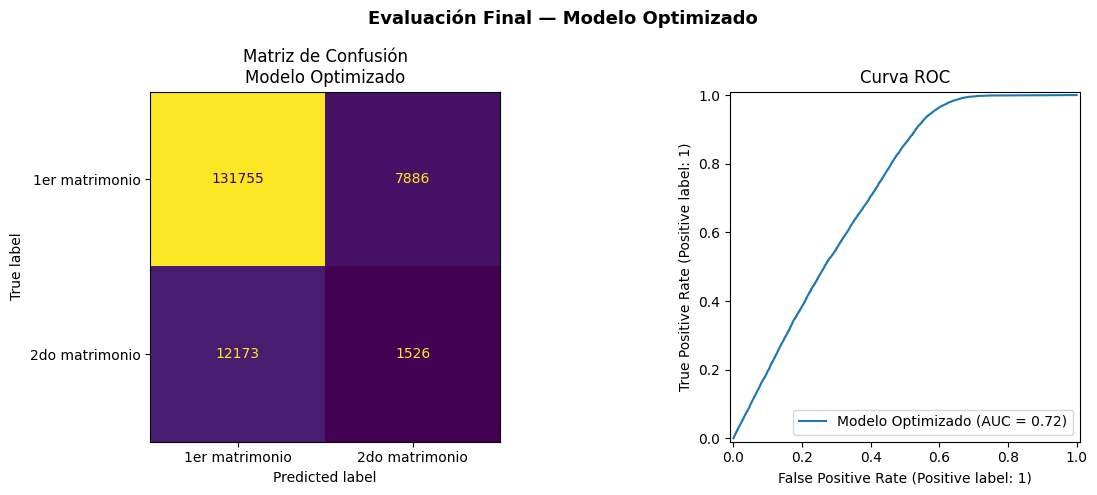

In [23]:
print(f"\n{'='*10} REPORTE FINAL — {label_final} {'='*10}")
print(f"Accuracy  : {accuracy_score(y_test_final, pred_final):.4f}")
print(f"Precision : {precision_score(y_test_final, pred_final, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test_final, pred_final, zero_division=0):.4f}")
print(f"F1-score  : {f1_score(y_test_final, pred_final, zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_final, probs_final):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_final, pred_final, zero_division=0))

# Matriz de confusión + Curva ROC en la misma figura
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix(y_test_final, pred_final, label_final, ax=axes[0])
plot_roc(modelo_final, X_test_final, y_test_final, label_final, ax=axes[1])
plt.suptitle(f"Evaluación Final — {label_final}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("evaluacion_final.png", dpi=150)
plt.show()

## Paso 10 · Importancia de Variables y Guardado

C:\Users\chris\AppData\Local\Temp\ipykernel_40704\3885470006.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importancia", y="Variable", data=df_imp, ax=ax, palette="Blues_r")


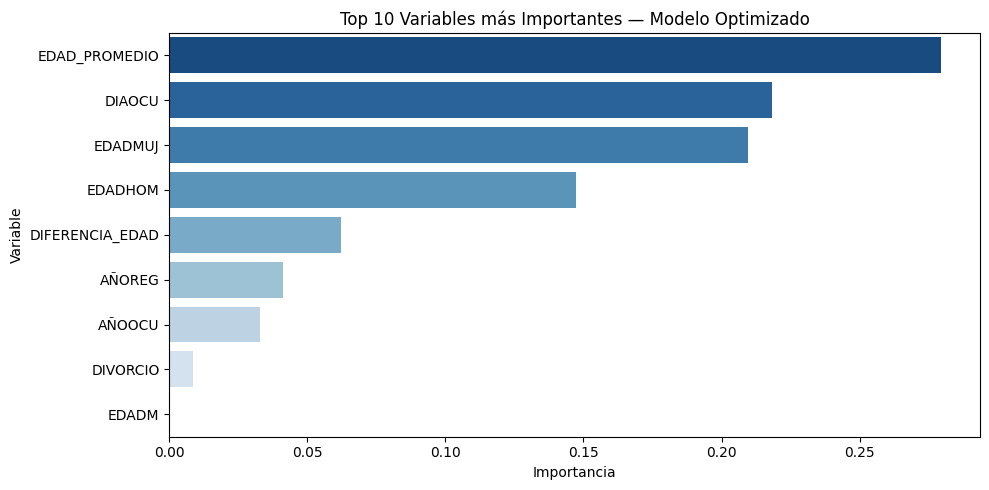


Top 10 variables más importantes:


,Variable,Importancia
8,EDAD_PROMEDIO,0.279633
4,DIAOCU,0.218366
3,EDADMUJ,0.209699
2,EDADHOM,0.147225
7,DIFERENCIA_EDAD,0.062258
0,AÑOREG,0.041258
1,AÑOOCU,0.032983
5,DIVORCIO,0.008568
6,EDADM,0.000010



✓ Archivos guardados:
  comparacion_modelos.csv
  importancia_variables.csv
  evaluacion_final.png


In [27]:
# ── Paso 10 · Importancia de variables y guardado ──────────────────────────

df_importancia = plot_importancia(modelo_final, cols_modelo, label_final, top_n=10)

print("\nTop 10 variables más importantes:")
display(df_importancia)

# Crear df_resultados con el modelo optimizado
df_resultados = pd.DataFrame([{
    "Modelo":    label_final,
    "Accuracy":  accuracy_score(y_test_final, pred_final),
    "F1-score":  f1_score(y_test_final, pred_final, average="weighted"),
    "ROC-AUC":   roc_auc_score(y_test_final, probs_final),
    "Precision": precision_score(y_test_final, pred_final, average="weighted", zero_division=0),
    "Recall":    recall_score(y_test_final, pred_final, average="weighted", zero_division=0),
}])

# Guardar resultados
df_resultados.to_csv("comparacion_modelos.csv", index=False)
df_importancia.to_csv("importancia_variables.csv", index=False)

print("\n✓ Archivos guardados:")
print("  comparacion_modelos.csv")
print("  importancia_variables.csv")
print("  evaluacion_final.png")